In [ ]:
from google.colab import drive
drive.flush_and_unmount()
print("Unmounted")

Drive not mounted, so nothing to flush and unmount.
Unmounted


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("Remounted")

Mounted at /content/drive
Remounted


In [3]:
import os
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Get the current working directory in Colab, usually /content
current_colab_cwd = os.getcwd()
print(f"Current Colab working directory: {current_colab_cwd}")

project_root_path = None
target_subdirectories = ['data', 'analysis', 'deep_learning']

# Walk through MyDrive to find the 'Exercise3' folder
for dirpath, dirnames, _ in os.walk('/content/drive/MyDrive'):
    # Check if 'Exercise3' is a subdirectory of the current dirpath
    if 'Exercise3' in dirnames:
        potential_project_root = os.path.join(dirpath, 'Exercise3')
        # Check if this potential root contains all target subdirectories
        if all(os.path.isdir(os.path.join(potential_project_root, sub_dir)) for sub_dir in target_subdirectories):
            project_root_path = potential_project_root
            break
    if Path(dirpath).name == 'Exercise3':
        if all(os.path.isdir(os.path.join(dirpath, sub_dir)) for sub_dir in target_subdirectories):
            project_root_path = dirpath
            break

if project_root_path:
    sys.path.append(project_root_path)
    print(f"Added project root to sys.path: {project_root_path}")
else:
    print("Warning: Could not automatically find the project root ('Exercise3' folder with 'data', 'analysis', 'deep_learning' subdirectories) in Google Drive.")
    print("Please ensure your project structure is correct and the 'Exercise3' folder is accessible in /content/drive/MyDrive.")
    print("You may need to manually adjust `sys.path.append()` to the correct path, e.g., `sys.path.append('/content/drive/MyDrive/YourFolder/Exercise3')`")

# Now try to import
try:
    from data.load_cifar import CIFAR10
    from data.load_gtsrb import GTSRB, GTSRB_CLASSES
    from analysis.evaluation import evaluate_model
    from deep_learning.cnn_transfer_learning import EfficientNetTransferModel
    from deep_learning.train_transfer_learning import (
        prepare_cifar10_loaders,
        prepare_gtsrb_loaders,
        train_transfer_learning
    )
    print("Modules imported successfully!")
except ModuleNotFoundError as e:
    print(f"Error importing modules even after path modification: {e}")
    print("Please double-check the 'Exercise3' folder structure and its location in Google Drive.")


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else
                     "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Create the outputs directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

Current Colab working directory: /content
Added project root to sys.path: /content/drive/MyDrive/Exercise3
Modules imported successfully!
Using device: cpu


# CIFAR SECTION


In [7]:
# --- CIFAR 5 frozen & 10 unfrozen model ---

# Load data
train_loader, test_loader, class_names = prepare_cifar10_loaders(
    batch_size=64,
    num_workers=2
)

print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

# Create model
model = EfficientNetTransferModel(
    num_classes=10,
    dropout=0.3,
    pretrained=True
)
print(f"Total params: {model.get_total_params():,}")
print(f"Trainable params: {model.get_trainable_params():,}")

# Train
model, best_acc, history = train_transfer_learning(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs_frozen=5,
    epochs_unfrozen=10,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4,
    save_path='outputs/efficientnet_cifar10.pth'
)

print(f"\nBest validation accuracy: {best_acc:.4f}")

Training samples: 50000
Test samples: 10000
Total params: 4,020,358
Trainable params: 4,020,358

STAGE 1: Training classifier head (frozen backbone)

Epoch 1/5


KeyboardInterrupt: 

In [8]:
# Load best model
model.load_state_dict(torch.load('outputs/efficientnet_cifar10.pth', map_location=device))

# Evaluate with confusion matrix
results = evaluate_model(
    model=model,
    dataloader=test_loader,
    class_names=class_names,
    device=str(device),
    title="EfficientNet-B0 on CIFAR-10"
)

print(f"\nOverall Accuracy: {results['overall_accuracy']:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/efficientnet_cifar10.pth'

In [4]:
# --- CIFAR 10 frozen model ---

# Load data
train_loader, test_loader, class_names = prepare_cifar10_loaders(
    batch_size=64,
    num_workers=2
)

print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

# Create model
model = EfficientNetTransferModel(
    num_classes=10,
    dropout=0.3,
    pretrained=True
)
print(f"Total params: {model.get_total_params():,}")
print(f"Trainable params: {model.get_trainable_params():,}")

# Train
model, best_acc, history = train_transfer_learning(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs_frozen=10,
    epochs_unfrozen=0,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4,
    save_path='outputs/efficientnet_cifar10_no_unfreeze.pth'
)

print(f"\nBest validation accuracy: {best_acc:.4f}")

KeyboardInterrupt: 

In [9]:
# Load best model
model.load_state_dict(torch.load('outputs/efficientnet_cifar10_no_unfreeze.pth', map_location=device))

# Evaluate with confusion matrix
results = evaluate_model(
    model=model,
    dataloader=test_loader,
    class_names=class_names,
    device=str(device),
    title="EfficientNet-B0 on CIFAR-10 without unfreezing"
)

print(f"\nOverall Accuracy: {results['overall_accuracy']:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/efficientnet_cifar10_no_unfreeze.pth'

# GTSRB SECTION

In [ ]:
# --- Loading in GTSRB ---
# Load data DIRECTLY like your colleague
from data.load_gtsrb import GTSRB
from deep_learning.train_transfer_learning import get_gtsrb_augmentation, get_test_transform

gtsrb_data_dir = '/content/drive/MyDrive/Exercise3/data/GTSRB'
print(f"Using GTSRB data directory: {gtsrb_data_dir}")

train_path = os.path.join(gtsrb_data_dir, "Final_Training/Images")
test_path = os.path.join(gtsrb_data_dir, "Final_Test/Images")

train_ds = GTSRB(base_path=train_path, split="train", sample_fraction=1.0, transform=get_gtsrb_augmentation())
test_ds = GTSRB(base_path=test_path, split="test", sample_fraction=1.0, transform=get_test_transform())

gtsrb_train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
gtsrb_test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_ds)}")  # Should be 39,209
print(f"Test samples: {len(test_ds)}")      # Should be 12,630

Using GTSRB data directory: /content/drive/MyDrive/Exercise3/data/GTSRB
Loading GTSRB (train) from /content/drive/MyDrive/Exercise3/data/GTSRB/Final_Training/Images...
Loading GTSRB (test) from /content/drive/MyDrive/Exercise3/data/GTSRB/Final_Test/Images...
Training samples: 39352
Test samples: 12630


In [ ]:
# --- VALIDATING GTSRB ---

train_path = os.path.join(gtsrb_data_dir, "Final_Training/Images")

# Count folders (classes)
class_folders = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
print(f"Number of class folders: {len(class_folders)}")

# Count total images
total_images = 0
for class_folder in class_folders:
    class_path = os.path.join(train_path, class_folder)
    img_files = [f for f in os.listdir(class_path) if f.endswith(('.ppm', '.png', '.jpg'))]
    total_images += len(img_files)
    if len(img_files) < 100:  # Check if any class has suspiciously few images
        print(f"Class {class_folder}: {len(img_files)} images")

print(f"\nTotal images in filesystem: {total_images}")
print(f"Your dataset loading: {len(train_ds)}")
print(f"Missing: {total_images - len(train_ds)} images")

Number of class folders: 43

Total images in filesystem: 39352
Your dataset loading: 39352
Missing: 0 images


GTSRB TRAINING
Total params: 4,062,631
Trainable params: 4,062,631

STAGE 1: Training classifier head (frozen backbone)

Epoch 1/5


Train Loss: 1.6844 | Train Acc: 0.5463
Train Time: 308.76s
Val   Loss: 1.4050 | Val   Acc: 0.6000
Val   Time: 29.69s

Epoch 2/5


Train Loss: 1.1235 | Train Acc: 0.6712
Train Time: 304.56s
Val   Loss: 1.2494 | Val   Acc: 0.6265
Val   Time: 30.34s

Epoch 3/5


Train Loss: 1.0053 | Train Acc: 0.6957
Train Time: 312.90s
Val   Loss: 1.1854 | Val   Acc: 0.6468
Val   Time: 31.42s

Epoch 4/5


Train Loss: 0.9568 | Train Acc: 0.7066
Train Time: 310.01s
Val   Loss: 1.1516 | Val   Acc: 0.6528
Val   Time: 30.46s

Epoch 5/5


...

Train Loss: 0.2279 | Train Acc: 0.9286
Train Time: 307.61s
Val   Loss: 0.4461 | Val   Acc: 0.8562
Val   Time: 31.83s
✓ New best model saved! Val Acc: 0.8562

Epoch 12/15


Train Loss: 0.2097 | Train Acc: 0.9333
Train Time: 306.39s
Val   Loss: 0.4335 | Val   Acc: 0.8602
Val   Time: 29.32s
✓ New best model saved! Val Acc: 0.8602

Epoch 13/15


Train Loss: 0.2025 | Train Acc: 0.9355
Train Time: 308.75s
Val   Loss: 0.4222 | Val   Acc: 0.8635
Val   Time: 29.60s
✓ New best model saved! Val Acc: 0.8635

Epoch 14/15


Train Loss: 0.1954 | Train Acc: 0.9383
Train Time: 309.91s
Val   Loss: 0.4133 | Val   Acc: 0.8656
Val   Time: 31.18s
✓ New best model saved! Val Acc: 0.8656

Epoch 15/15


Train Loss: 0.1948 | Train Acc: 0.9372
Train Time: 309.08s
Val   Loss: 0.4124 | Val   Acc: 0.8656
Val   Time: 31.13s

Total Training Time  : 4634.24s
Total Validation Time: 463.61s
Training curves saved to transfer_learning_curves/training_curves_EfficientNetB0.png


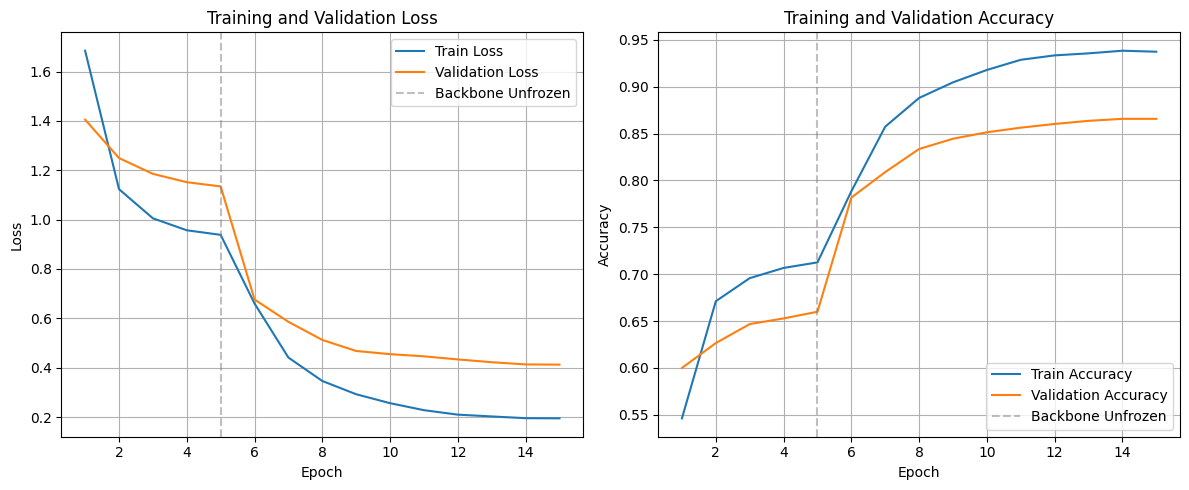


Best validation accuracy: 0.8656


In [ ]:
# --- GTSRB 5 frozen & 10 unfrozen model ---

print("="*70)
print("GTSRB TRAINING")
print("="*70)

# Create model for 43 classes (GTSRB)
model = EfficientNetTransferModel(
    num_classes=43,
    dropout=0.3,
    pretrained=True
)
print(f"Total params: {model.get_total_params():,}")
print(f"Trainable params: {model.get_trainable_params():,}")

# Train with GTSRB loaders
model, best_acc, history = train_transfer_learning(
    model=model,
    train_loader=gtsrb_train_loader,
    test_loader=gtsrb_test_loader,
    device=device,
    epochs_frozen=5,
    epochs_unfrozen=10,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4,
    save_path='outputs/efficientnet_gtsrb.pth'
)

print(f"\nBest validation accuracy: {best_acc:.4f}")

GTSRB EVALUATION

EfficientNet-B0 on GTSRB
------------------------
Overall accuracy: 0.8656

Per-class accuracy:
  Speed 20: 0.300
  Speed 30: 0.776
  Speed 50: 0.888
  Speed 60: 0.753
  Speed 70: 0.902
  Speed 80: 0.876
End Speed 80: 0.820
 Speed 100: 0.933
 Speed 120: 0.871
No passing: 0.935
No passing >3.5t: 0.958
Right-of-way: 0.871
Priority road: 0.993
     Yield: 0.993
      Stop: 0.993
No vehicles: 0.990
Veh >3.5t prohib: 0.940
  No entry: 0.953
General caution: 0.772
Curve left: 0.483
Curve right: 0.589
Double curve: 0.656
Bumpy road: 0.725
  Slippery: 0.773
Narrows right: 0.811
 Road work: 0.879
Traffic signals: 0.872
Pedestrians: 0.467
  Children: 0.627
  Bicycles: 0.889
  Ice/Snow: 0.733
Wild animals: 0.926
End limits: 0.883
Turn right: 0.762
 Turn left: 0.758
Ahead only: 0.890
Straight/Right: 0.558
Straight/Left: 0.267
Keep right: 0.974
 Keep left: 0.344
Roundabout: 0.844
End no passing: 0.567
End no pass >3.5t: 0.622

Classification report:
                   precision   

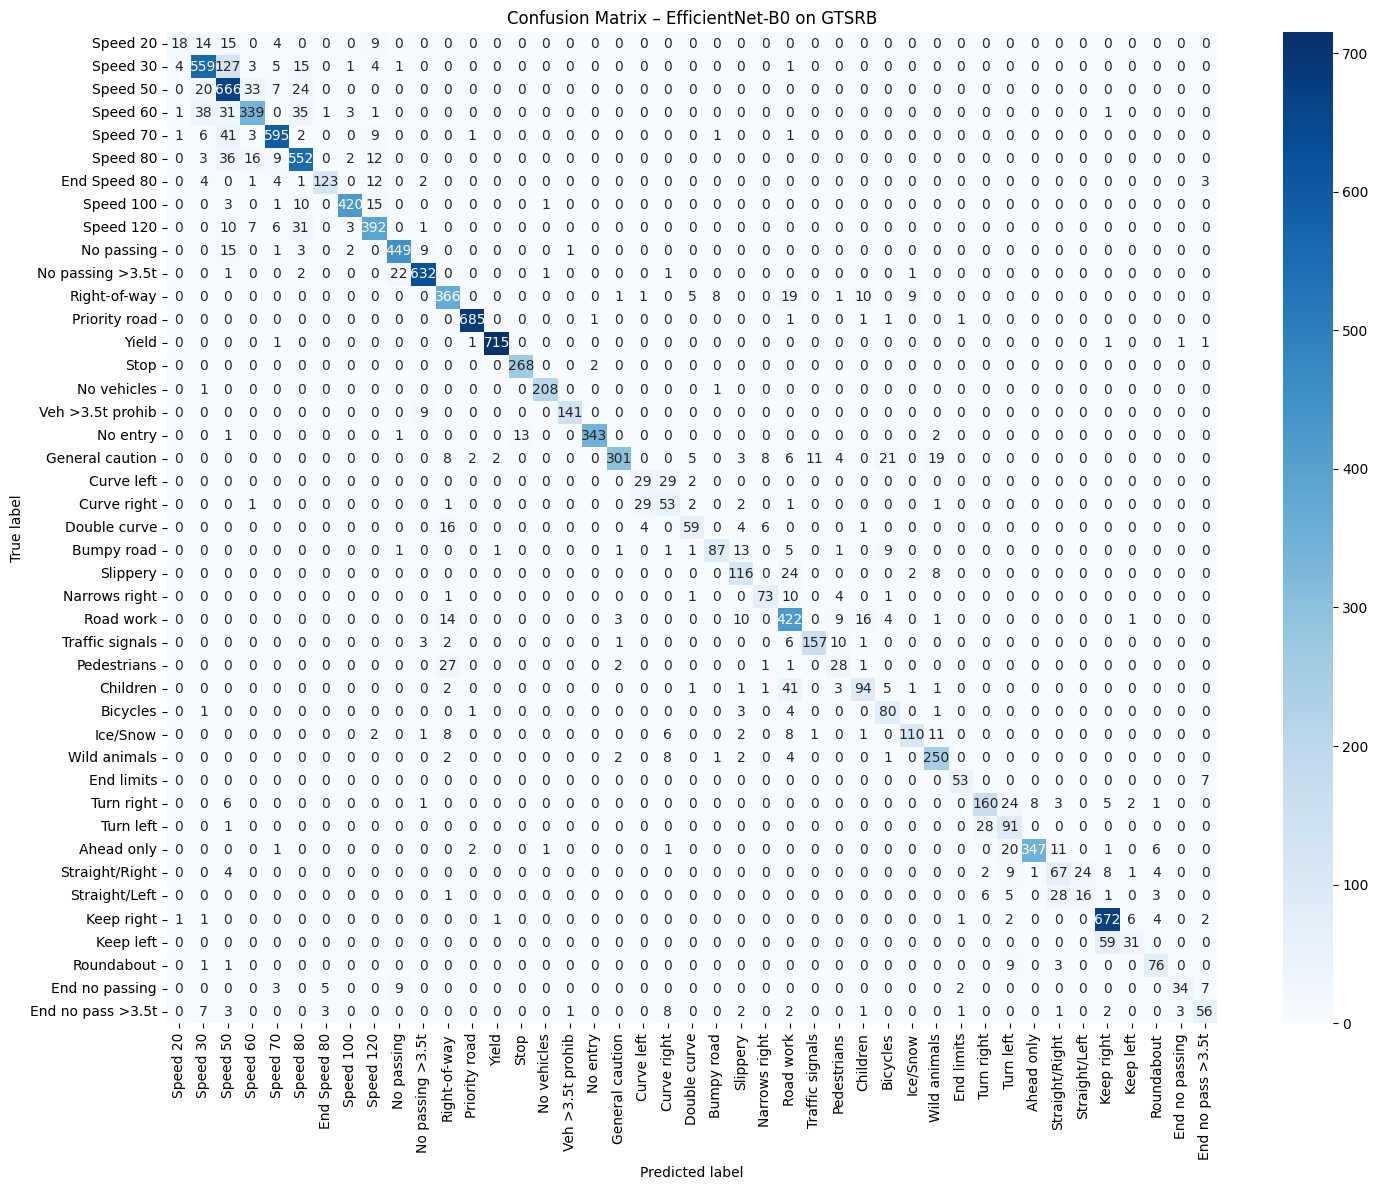


Overall Accuracy: 0.8656


In [ ]:
print("="*70)
print("GTSRB EVALUATION")
print("="*70)

# Load best model
model.load_state_dict(torch.load('outputs/efficientnet_gtsrb.pth', map_location=device))

# Define gtsrb_class_names from the GTSRB_CLASSES dictionary
gtsrb_class_names = list(GTSRB_CLASSES.values())

# Evaluate with GTSRB data
results = evaluate_model(
    model=model,
    dataloader=gtsrb_test_loader,
    class_names=gtsrb_class_names,
    device=str(device),
    title="EfficientNet-B0 on GTSRB",
    figsize=(15, 12)
)

print(f"\nOverall Accuracy: {results['overall_accuracy']:.4f}")

In [ ]:
# --- GTSRB 10 frozen model ---

print("="*70)
print("GTSRB NO UNFREEZING TRAINING")
print("="*70)

# Create model for 43 classes (GTSRB)
model = EfficientNetTransferModel(
    num_classes=43,
    dropout=0.3,
    pretrained=True
)
print(f"Total params: {model.get_total_params():,}")
print(f"Trainable params: {model.get_trainable_params():,}")

# Train with GTSRB loaders
model, best_acc, history = train_transfer_learning(
    model=model,
    train_loader=gtsrb_train_loader,  # GTSRB data
    test_loader=gtsrb_test_loader,    # GTSRB data
    device=device,
    epochs_frozen=10,
    epochs_unfrozen=0,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4,
    save_path='outputs/efficientnet_gtsrb_no_unfreeze.pth'
)

print(f"\nBest validation accuracy: {best_acc:.4f}")

GTSRB EVALUATION

EfficientNet-B0 on GTSRB
------------------------
Overall accuracy: 0.8656

Per-class accuracy:
  Speed 20: 0.300
  Speed 30: 0.776
  Speed 50: 0.888
  Speed 60: 0.753
  Speed 70: 0.902
  Speed 80: 0.876
End Speed 80: 0.820
 Speed 100: 0.933
 Speed 120: 0.871
No passing: 0.935
No passing >3.5t: 0.958
Right-of-way: 0.871
Priority road: 0.993
     Yield: 0.993
      Stop: 0.993
No vehicles: 0.990
Veh >3.5t prohib: 0.940
  No entry: 0.953
General caution: 0.772
Curve left: 0.483
Curve right: 0.589
Double curve: 0.656
Bumpy road: 0.725
  Slippery: 0.773
Narrows right: 0.811
 Road work: 0.879
Traffic signals: 0.872
Pedestrians: 0.467
  Children: 0.627
  Bicycles: 0.889
  Ice/Snow: 0.733
Wild animals: 0.926
End limits: 0.883
Turn right: 0.762
 Turn left: 0.758
Ahead only: 0.890
Straight/Right: 0.558
Straight/Left: 0.267
Keep right: 0.974
 Keep left: 0.344
Roundabout: 0.844
End no passing: 0.567
End no pass >3.5t: 0.622

Classification report:
                   precision   

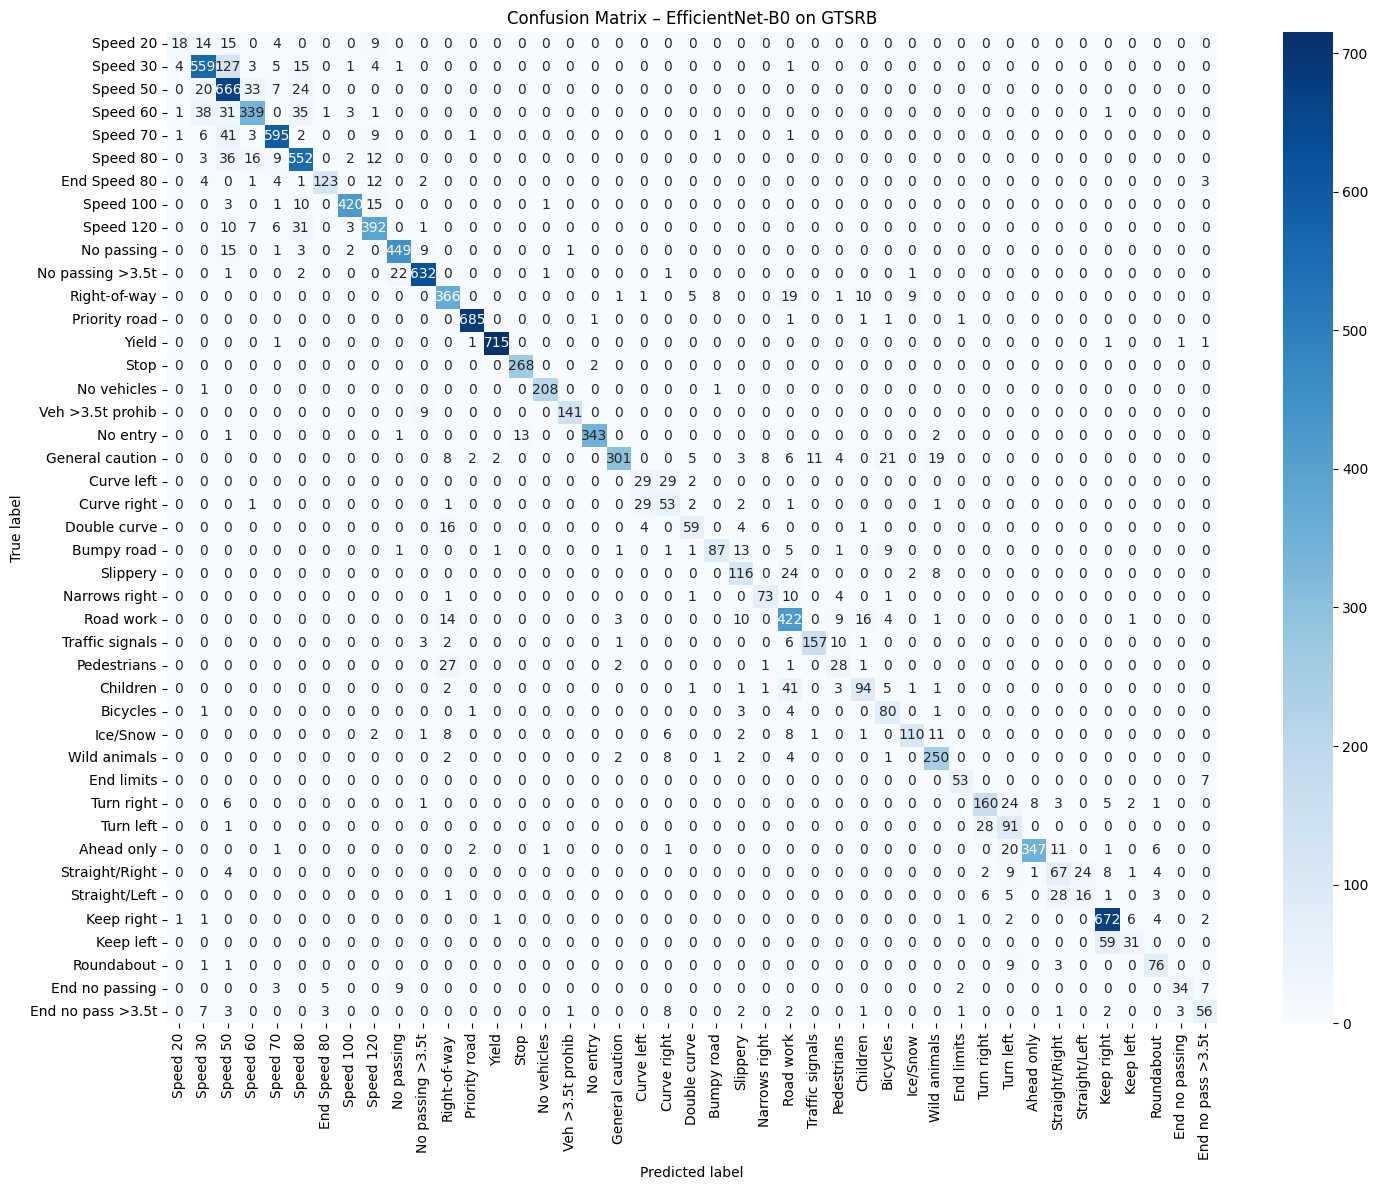


Overall Accuracy: 0.8656


In [ ]:
print("="*70)
print("GTSRB FROZEN EVALUATION")
print("="*70)

# Load best model
model.load_state_dict(torch.load('outputs/efficientnet_gtsrb_no_unfreeze.pth', map_location=device))

# Define gtsrb_class_names from the GTSRB_CLASSES dictionary
gtsrb_class_names = list(GTSRB_CLASSES.values())

# Evaluate with GTSRB data
results = evaluate_model(
    model=model,
    dataloader=gtsrb_test_loader,
    class_names=gtsrb_class_names,
    device=str(device),
    title="EfficientNet-B0 on GTSRB without unfreezing",
    figsize=(15, 12)
)

print(f"\nOverall Accuracy: {results['overall_accuracy']:.4f}")